In [2]:
!pip install kaggle --quiet

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from torchvision.models import (
    ResNet50_Weights, EfficientNet_B0_Weights, MobileNet_V2_Weights
)

import numpy as np
import matplotlib.pyplot as plt
import time
import os
import copy
from pathlib import Path

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch version: {torch.__version__}')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

torch.manual_seed(42)
np.random.seed(42)

PyTorch version: 2.11.0+cu128
Device: cuda
GPU: Tesla T4


In [3]:
from google.colab import files
import json

uploaded = files.upload()

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write(list(uploaded.values())[0].decode())
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print('✅ kaggle.json saved')

Saving kaggle.json to kaggle.json
✅ kaggle.json saved


In [5]:
DATA_ROOT = Path('/content/plantvillage')

if not DATA_ROOT.exists():
    print('Downloading PlantVillage dataset (~1.5 GB, ~2 min)...')
    !kaggle datasets download -d abdallahalidev/plantvillage-dataset -p /content --unzip --quiet
    import shutil
    src = Path('/content/plantvillage dataset/color')
    shutil.copytree(src, DATA_ROOT)
    print('Dataset ready at', DATA_ROOT)
else:
    print('Dataset already downloaded')

all_classes = sorted([d.name for d in DATA_ROOT.iterdir() if d.is_dir()])
print(f'Total classes: {len(all_classes)}')
print('First 10:', all_classes[:10])

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
Dataset ready at /content/plantvillage
Total classes: 38
First 10: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight']


In [6]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 8
NUM_CLASSES = 5
NUM_WORKERS = 2

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

full_dataset = datasets.ImageFolder(DATA_ROOT)
class_names = full_dataset.classes
print(f'Full dataset: {len(full_dataset)} images, {len(class_names)} classes')

selected_classes = class_names[:NUM_CLASSES]
indices = [i for i, (_, label) in enumerate(full_dataset.samples) if label < NUM_CLASSES]
print(f'Filtered to {NUM_CLASSES} classes: {len(indices)} images')
print('Classes:', selected_classes)

np.random.shuffle(indices)
split = int(0.8 * len(indices))
train_idx = indices[:split]
val_idx = indices[split:]

class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img, label = self.dataset[self.indices[idx]]
        return self.transform(img), label

full_dataset.transform = None

train_dataset = TransformSubset(full_dataset, train_idx, train_transforms)
val_dataset = TransformSubset(full_dataset, val_idx,   val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f'\nTrain batches: {len(train_loader)} | Val batches: {len(val_loader)}')
imgs, lbls = next(iter(train_loader))
print(f'Batch shape: {imgs.shape}  (B, C, H, W) — PyTorch is channel-first!')

Full dataset: 54305 images, 38 classes
Filtered to 5 classes: 4673 images
Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']

Train batches: 117 | Val batches: 30
Batch shape: torch.Size([32, 3, 224, 224])  (B, C, H, W) — PyTorch is channel-first!


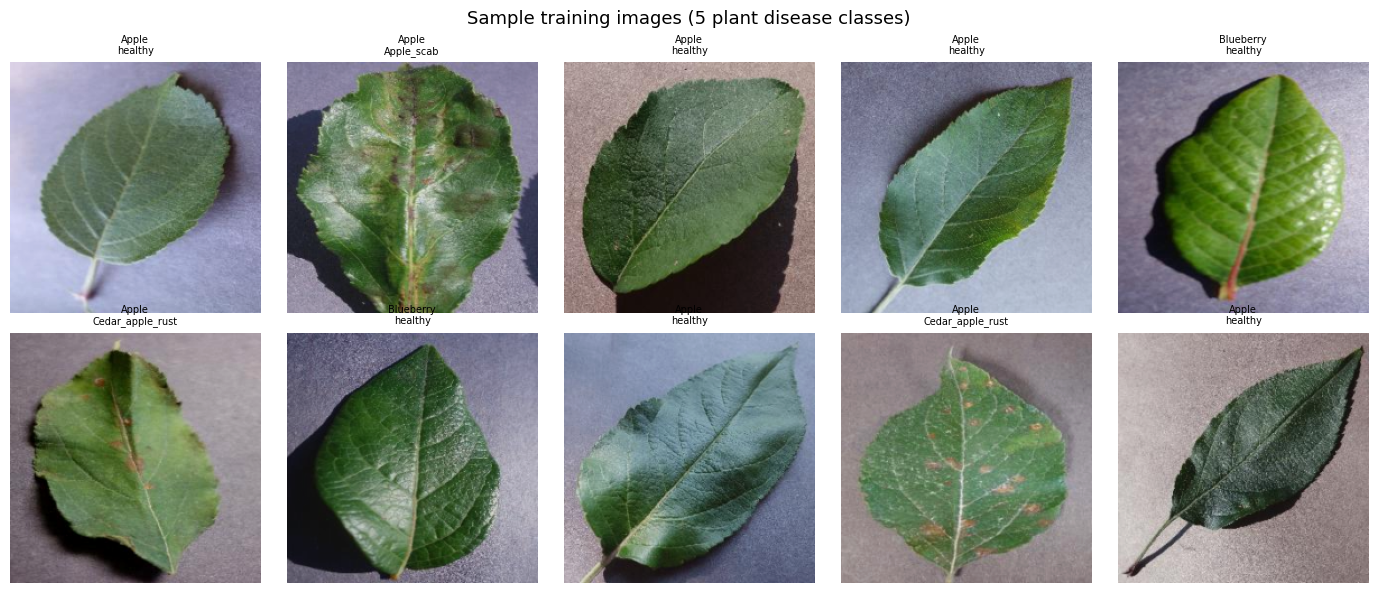

In [7]:
def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Sample training images (5 plant disease classes)', fontsize=13)

imgs, lbls = next(iter(train_loader))
for i, ax in enumerate(axes.flat):
    img_show = denormalize(imgs[i]).permute(1, 2, 0).numpy()
    ax.imshow(img_show)
    ax.set_title(selected_classes[lbls[i].item()].replace('___', '\n'), fontsize=7)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [8]:
def build_model(arch_name, num_classes):
    if arch_name == 'resnet50':
        model = models.resnet50(weights=ResNet50_Weights.DEFAULT)
        feature_dim = model.fc.in_features

        # Freeze entire backbone
        for param in model.parameters():
            param.requires_grad = False

        # Replace head - ResNet50 uses model.fc
        model.fc = nn.Sequential(
            nn.Linear(feature_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    elif arch_name == 'efficientnet_b0':
        model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        feature_dim = model.classifier[1].in_features

        for param in model.parameters():
            param.requires_grad = False

        # EfficientNet uses model.classifier (Sequential)
        model.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(feature_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

    elif arch_name == 'mobilenet_v2':
        model = models.mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)
        feature_dim = model.classifier[1].in_features

        for param in model.parameters():
            param.requires_grad = False

        # MobileNetV2 also uses model.classifier
        model.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(feature_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

    else:
        raise ValueError(f'Unknown arch: {arch_name}')

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    print(f'{arch_name:<18} | trainable: {trainable:>8,} | frozen: {frozen:>10,}')

    return model.to(DEVICE), feature_dim


print('Building models (ImageNet weights download on first run)...')
print(f'{"Model":<20} | {"Trainable":>10} | {"Frozen":>12}')

model_resnet, _ = build_model('resnet50', NUM_CLASSES)
model_eff, _ = build_model('efficientnet_b0', NUM_CLASSES)
model_mobile, _ = build_model('mobilenet_v2', NUM_CLASSES)

print(f'\nAll 3 models built and moved to {DEVICE}')

Building models (ImageNet weights download on first run)...
Model                |  Trainable |       Frozen
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 157MB/s]


resnet50           | trainable:  525,829 | frozen: 23,508,032
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 141MB/s]


efficientnet_b0    | trainable:  329,221 | frozen:  4,007,548
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 72.4MB/s]


mobilenet_v2       | trainable:  329,221 | frozen:  2,223,872

All 3 models built and moved to cuda


In [17]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def train_model(model, train_loader, val_loader, epochs, name):
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=1e-3
    )
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=2
    )

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    best_val_acc = 0.0
    best_weights = None
    patience_count = 0
    EARLY_STOP_PAT = 3

    print(f'Training {name}...\n')

    t_start = time.time()

    for epoch in range(1, epochs + 1):
        t_ep = time.time()

        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss,   val_acc   = evaluate(model, val_loader, criterion)

        scheduler.step(val_acc)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        ep_time = time.time() - t_ep
        print(f'Epoch {epoch:2d}/{epochs} | '
              f'train_acc: {train_acc:.4f} | '
              f'val_acc: {val_acc:.4f} | '
              f'val_loss: {val_loss:.4f} | '
              f'{ep_time:.0f}s')

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= EARLY_STOP_PAT:
                print(f'Early stopping at epoch {epoch}')
                break

    model.load_state_dict(best_weights)
    train_time = time.time() - t_start

    print(f'\n{name} done - Best val acc: {best_val_acc:.4f} | Time: {train_time:.0f}s')
    return history, train_time

In [18]:
history_resnet, time_resnet = train_model(model_resnet, train_loader, val_loader, EPOCHS, 'ResNet50')
history_eff, time_eff = train_model(model_eff, train_loader, val_loader, EPOCHS, 'EfficientNetB0')
history_mobile, time_mobile = train_model(model_mobile, train_loader, val_loader, EPOCHS, 'MobileNetV2')

Training ResNet50...

Epoch  1/8 | train_acc: 0.9473 | val_acc: 0.9722 | val_loss: 0.0843 | 21s
Epoch  2/8 | train_acc: 0.9799 | val_acc: 0.9818 | val_loss: 0.0529 | 24s
Epoch  3/8 | train_acc: 0.9874 | val_acc: 0.9829 | val_loss: 0.0427 | 26s
Epoch  4/8 | train_acc: 0.9909 | val_acc: 0.9904 | val_loss: 0.0278 | 23s
Epoch  5/8 | train_acc: 0.9904 | val_acc: 0.9807 | val_loss: 0.0716 | 27s
Epoch  6/8 | train_acc: 0.9941 | val_acc: 0.9936 | val_loss: 0.0229 | 29s
Epoch  7/8 | train_acc: 0.9955 | val_acc: 0.9882 | val_loss: 0.0330 | 26s
Epoch  8/8 | train_acc: 0.9979 | val_acc: 0.9925 | val_loss: 0.0297 | 27s

ResNet50 done - Best val acc: 0.9936 | Time: 202s
Training EfficientNetB0...

Epoch  1/8 | train_acc: 0.9058 | val_acc: 0.9786 | val_loss: 0.0718 | 24s
Epoch  2/8 | train_acc: 0.9724 | val_acc: 0.9829 | val_loss: 0.0478 | 25s
Epoch  3/8 | train_acc: 0.9724 | val_acc: 0.9840 | val_loss: 0.0443 | 23s
Epoch  4/8 | train_acc: 0.9732 | val_acc: 0.9850 | val_loss: 0.0387 | 28s
Epoch  5/8 

In [19]:
@torch.no_grad()
def measure_inference_time(model, loader, n_batches=5):
    model.eval()

    for images, _ in loader:
        _ = model(images.to(DEVICE))
        break

    total_images, total_time = 0, 0.0

    for i, (images, _) in enumerate(loader):
        if i >= n_batches:
            break
        images = images.to(DEVICE)

        if DEVICE.type == 'cuda':
            torch.cuda.synchronize()

        t0 = time.time()
        _  = model(images)

        if DEVICE.type == 'cuda':
            torch.cuda.synchronize()

        total_time += time.time() - t0
        total_images += images.size(0)

    return round((total_time / total_images) * 1000, 2)


def get_model_size_mb(model, path='/tmp/model_tmp.pth'):
    torch.save(model.state_dict(), path)
    size_mb = os.path.getsize(path) / (1024 * 1024)
    os.remove(path)
    return round(size_mb, 1)


print('Measuring inference speeds...')
speed_resnet = measure_inference_time(model_resnet, val_loader)
speed_eff = measure_inference_time(model_eff, val_loader)
speed_mobile = measure_inference_time(model_mobile, val_loader)

print('Measuring model sizes...')
size_resnet = get_model_size_mb(model_resnet)
size_eff = get_model_size_mb(model_eff)
size_mobile = get_model_size_mb(model_mobile)

print(f'\nResNet50: {speed_resnet} ms/img | {size_resnet} MB')
print(f'EfficientNetB0 : {speed_eff} ms/img | {size_eff} MB')
print(f'MobileNetV2: {speed_mobile} ms/img | {size_mobile} MB')

Measuring inference speeds...
Measuring model sizes...

ResNet50: 3.35 ms/img | 92.0 MB
EfficientNetB0 : 1.2 ms/img | 16.8 MB
MobileNetV2: 1.03 ms/img | 10.0 MB


In [20]:
results = {
    'ResNet50': {
        'val_acc': max(history_resnet['val_acc']),
        'train_time': time_resnet,
        'speed_ms':speed_resnet,
        'size_mb': size_resnet,
        'history': history_resnet,
        'color': '#4A6FA5'
    },
    'EfficientNetB0': {
        'val_acc': max(history_eff['val_acc']),
        'train_time': time_eff,
        'speed_ms': speed_eff,
        'size_mb': size_eff,
        'history':history_eff,
        'color': '#2D9B6F'
    },
    'MobileNetV2': {
        'val_acc': max(history_mobile['val_acc']),
        'train_time': time_mobile,
        'speed_ms': speed_mobile,
        'size_mb': size_mobile,
        'history': history_mobile,
        'color': '#C0663A'
    }
}

print(f'{"Model":<18} {"Val Acc":>8} {"Size":>8} {"Inference":>12} {"Train Time":>12}')
for name, m in results.items():
    print(f'{name:<18} {m["val_acc"]:>7.1%} {m["size_mb"]:>7.1f}MB '
          f'{m["speed_ms"]:>9.1f}ms {m["train_time"]/60:>9.1f}min')

Model               Val Acc     Size    Inference   Train Time
ResNet50             99.4%    92.0MB       3.4ms       3.4min
EfficientNetB0       98.9%    16.8MB       1.2ms       2.9min
MobileNetV2          99.4%    10.0MB       1.0ms       1.5min


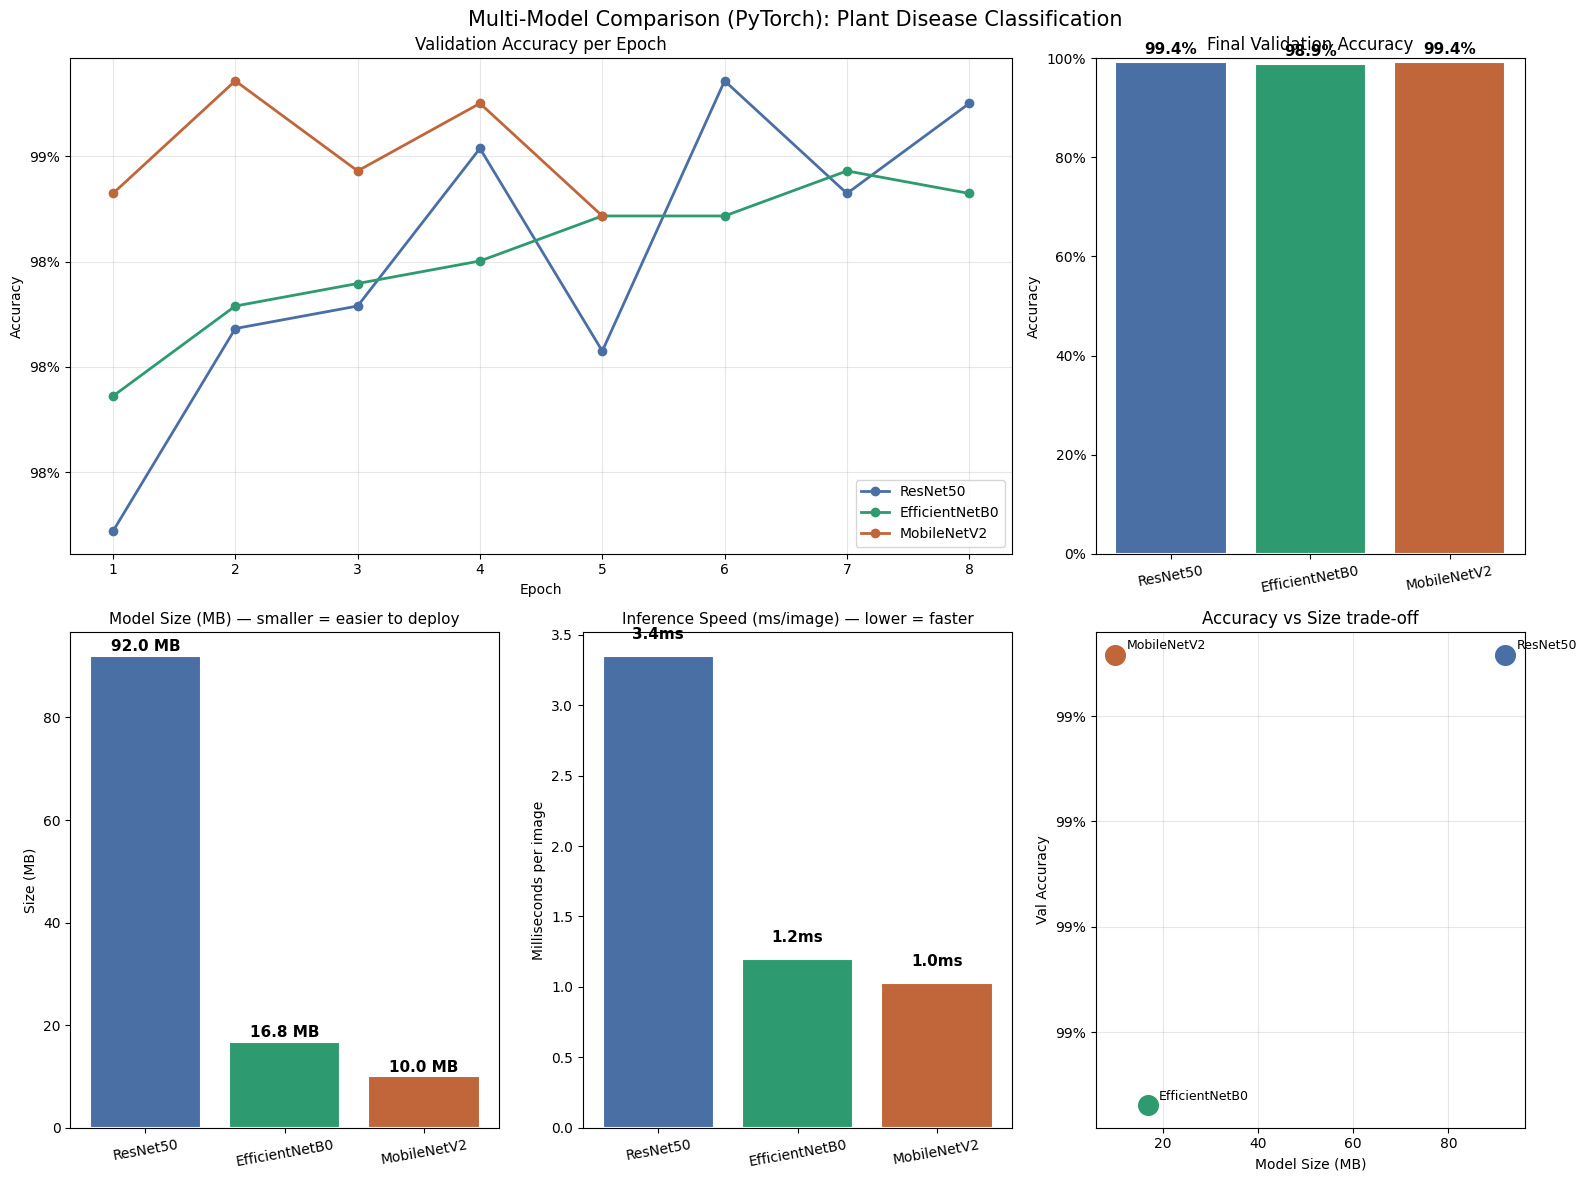

Saved: model_comparison_pytorch.png


In [21]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Multi-Model Comparison (PyTorch): Plant Disease Classification', fontsize=15, y=0.98)

names = list(results.keys())
colors = [results[n]['color'] for n in names]

ax1 = fig.add_subplot(2, 3, (1, 2))
for name, m in results.items():
    val_acc = m['history']['val_acc']
    ax1.plot(range(1, len(val_acc)+1), val_acc, marker='o', label=name, color=m['color'], linewidth=2)
ax1.set_title('Validation Accuracy per Epoch', fontsize=12)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

ax2 = fig.add_subplot(2, 3, 3)
accs = [results[n]['val_acc'] for n in names]
bars = ax2.bar(names, accs, color=colors, edgecolor='white', linewidth=1.5)
ax2.set_title('Final Validation Accuracy', fontsize=12)
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
for bar, acc in zip(bars, accs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{acc:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.tick_params(axis='x', rotation=10)

ax3 = fig.add_subplot(2, 3, 4)
sizes = [results[n]['size_mb'] for n in names]
bars3 = ax3.bar(names, sizes, color=colors, edgecolor='white', linewidth=1.5)
ax3.set_title('Model Size (MB) — smaller = easier to deploy', fontsize=11)
ax3.set_ylabel('Size (MB)')
for bar, s in zip(bars3, sizes):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{s:.1f} MB', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax3.tick_params(axis='x', rotation=10)

ax4 = fig.add_subplot(2, 3, 5)
speeds = [results[n]['speed_ms'] for n in names]
bars4 = ax4.bar(names, speeds, color=colors, edgecolor='white', linewidth=1.5)
ax4.set_title('Inference Speed (ms/image) — lower = faster', fontsize=11)
ax4.set_ylabel('Milliseconds per image')
for bar, sp in zip(bars4, speeds):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{sp:.1f}ms', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax4.tick_params(axis='x', rotation=10)

ax5 = fig.add_subplot(2, 3, 6)
for name, m in results.items():
    ax5.scatter(m['size_mb'], m['val_acc'], s=200, color=m['color'], zorder=5)
    ax5.annotate(name, (m['size_mb'], m['val_acc']), textcoords='offset points', xytext=(8, 4), fontsize=9)
ax5.set_title('Accuracy vs Size trade-off', fontsize=12)
ax5.set_xlabel('Model Size (MB)')
ax5.set_ylabel('Val Accuracy')
ax5.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax5.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison_pytorch.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_comparison_pytorch.png')

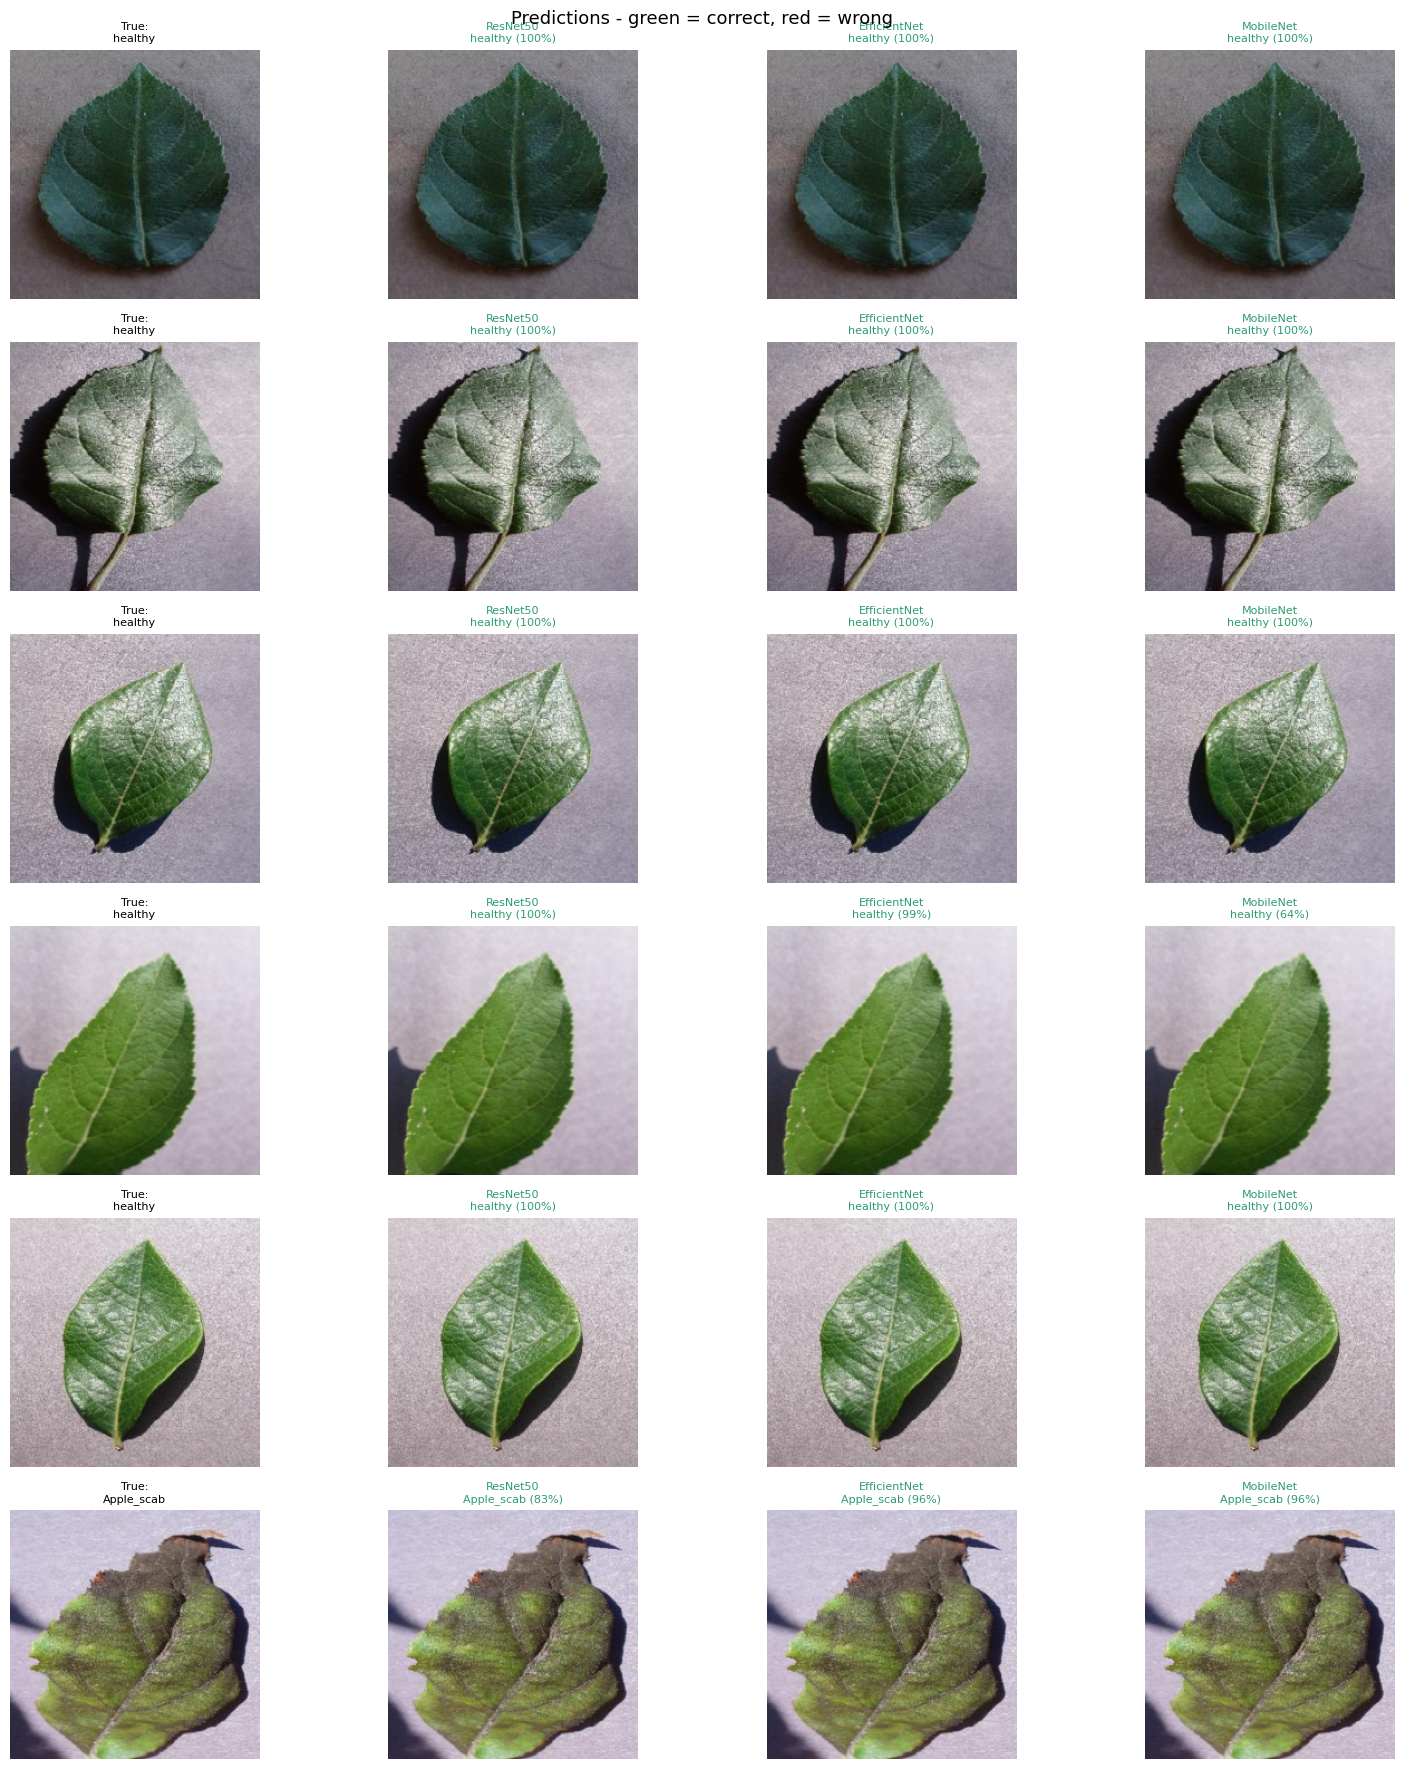

In [22]:
@torch.no_grad()
def predict_sample(models_dict, loader, class_names, n_samples=6):
    imgs, labels = next(iter(loader))
    imgs = imgs[:n_samples]
    labels = labels[:n_samples]

    model_list = list(models_dict.items())
    fig, axes = plt.subplots(n_samples, len(model_list) + 1, figsize=(4 * (len(model_list)+1), 3 * n_samples))

    for i in range(n_samples):
        img_show = denormalize(imgs[i]).permute(1, 2, 0).numpy()
        label = labels[i].item()
        axes[i, 0].imshow(img_show)
        axes[i, 0].set_title(f'True:\n{class_names[label].split("___")[-1]}',
                              fontsize=8)
        axes[i, 0].axis('off')

        for j, (mname, model) in enumerate(model_list):
            model.eval()
            logits  = model(imgs[i].unsqueeze(0).to(DEVICE))
            probs = torch.softmax(logits, dim=1)[0].cpu()
            pred_class = probs.argmax().item()
            pred_conf = probs[pred_class].item()
            correct= pred_class == label
            color = '#2D9B6F' if correct else '#C0663A'

            axes[i, j+1].imshow(img_show)
            axes[i, j+1].set_title(
                f'{mname}\n{class_names[pred_class].split("___")[-1]} ({pred_conf:.0%})', fontsize=8, color=color
            )
            axes[i, j+1].axis('off')

    fig.suptitle('Predictions - green = correct, red = wrong', fontsize=13)
    plt.tight_layout()
    plt.show()


predict_sample(
    models_dict = {'ResNet50': model_resnet, 'EfficientNet': model_eff, 'MobileNet': model_mobile},
    loader = val_loader,
    class_names = selected_classes,
    n_samples = 6
)

In [23]:
best_name = max(results, key=lambda n: results[n]['val_acc'])
best_model = {'ResNet50': model_resnet,
              'EfficientNetB0': model_eff,
              'MobileNetV2': model_mobile}[best_name]

print(f'Best model: {best_name}')
print(f'Val accuracy before fine-tuning: {results[best_name]["val_acc"]:.2%}')

all_params = list(best_model.parameters())
n_unfreeze = max(1, len(all_params) // 5)

for param in all_params[-n_unfreeze:]:
    param.requires_grad = True

newly_trainable = sum(p.numel() for p in best_model.parameters() if p.requires_grad)
print(f'Trainable params after unfreezing: {newly_trainable:,}')

ft_optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, best_model.parameters()),
    lr=1e-5   # 100x smaller than feature extraction LR
)
criterion = nn.CrossEntropyLoss()

print('\nFine-tuning for 5 epochs...')
ft_val_accs = []
best_ft_acc = 0.0
best_ft_state = None

for epoch in range(1, 6):
    train_loss, train_acc = train_one_epoch(best_model, train_loader, criterion, ft_optimizer)
    val_loss, val_acc = evaluate(best_model, val_loader, criterion)
    ft_val_accs.append(val_acc)

    if val_acc > best_ft_acc:
        best_ft_acc = val_acc
        best_ft_state = copy.deepcopy(best_model.state_dict())

    print(f'FT Epoch {epoch}/5 | train_acc: {train_acc:.4f} | val_acc: {val_acc:.4f}')

best_model.load_state_dict(best_ft_state)

gain = best_ft_acc - results[best_name]['val_acc']
print(f'\nBefore fine-tuning: {results[best_name]["val_acc"]:.2%}')
print(f'After fine-tuning: {best_ft_acc:.2%}')
print(f'Improvement: +{gain:.2%}')
print(f'Worth it? {"Yes! Great gain." if gain > 0.01 else "Marginal - consider more data or longer training."}')

Best model: ResNet50
Val accuracy before fine-tuning: 99.36%
Trainable params after unfreezing: 14,965,765

Fine-tuning for 5 epochs...
FT Epoch 1/5 | train_acc: 0.9963 | val_acc: 0.9904
FT Epoch 2/5 | train_acc: 0.9979 | val_acc: 0.9904
FT Epoch 3/5 | train_acc: 0.9992 | val_acc: 0.9925
FT Epoch 4/5 | train_acc: 0.9979 | val_acc: 0.9936
FT Epoch 5/5 | train_acc: 0.9992 | val_acc: 0.9968

Before fine-tuning: 99.36%
After fine-tuning: 99.68%
Improvement: +0.32%
Worth it? Marginal - consider more data or longer training.


### Deployment Decision

| Scenario | Best Choice |
|---|---|
| Web API (accuracy matters) | ResNet50 |
| Mobile / edge device | MobileNetV2 |
| Balanced (best default) | EfficientNetB0 |
| Large dataset available | Fine-tune EfficientNetB0 |